--------------------------------------------------
# CAJA DE HERRAMIENTAS 
Para utilizar esta cosa, revisa la lista de abajo y busca lo que necesitas

utiliza ctrl + f para abrir el buscador de palabras, de la siguiente manera, asi te lleva altiro a lo que estas buscando

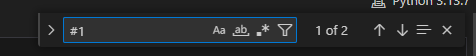

#1 LIBRERIAS

#2 DESCOMPRIMIR

#3 LECTURA

#4 LIMPIEZA Y FORMATO

    #4.1 Eliminar muestras con datos nulo entre sus columnas

    #4.2 Botar columnas especificas

    #4.3 Identificar y eliminar datos duplicados

    #4.4 Verificar que los tipos de datos sean adecuados y corregir de ser necesario. Columna `fecha` este en el formato adecuado

    #4.5 Elegir categoría

    #4.6 Unir dataframes (Merge y Concat y Merge)

    #4.7 Outliers

    #4.8 Analisis distributivo

    #4.9 Estadisticas y agrupación

#5 Apply

# Funciones matematica

#6 EDA
    EDA segun chatgipiti

#7 GRAFICOS

    #7.1 Grafico Barra
    #7.2 Grafico Agrupadas Horizontalmente
    #7.3 Gratifo de barras apiladas
    #7.4 Grafico de barras apiladas con porcentaje
    #7.5 Histograma
    #7.6 Diagrama de caja/Boxplot (para mostrar rango y outliers, para ver la media)
    #7.7 Lineplot
    #7.8 Estadisticas


#8 CORRELACION

#9 Tipo de escalamiento

#10 REGRESIÓN 

#11 REGRESION POLINOMIAL

------------------------------------------------------------------------------



📊 Análisis y visualización de datos

1. numpy as np 

    Para cálculos numéricos eficientes: arrays, operaciones vectorizadas, estadísticas básicas.

2. pandas as pd

    Manipulación de datos estructurados: DataFrames, limpieza, filtrado, agrupamiento, lectura/escritura de archivos.

3. matplotlib.pyplot as plt

    Visualización básica: gráficos de líneas, barras, dispersión, histogramas. Control detallado de ejes, leyendas y estilos.

4. seaborn as sns

    Visualización estadística avanzada sobre matplotlib: gráficos de correlación, KDE, boxplots, heatmaps con estética mejorada.

5. plotly.express as px 

    Visualizaciones interactivas: gráficos dinámicos, zoom, tooltips. Ideal para dashboards y exploración visual

6. zipfile 

    Lectura y escritura de archivos .zip: extracción, compresión, inspección de contenido.

7. os 

    Interacción con el sistema operativo: rutas, nombres de archivos, creación/eliminación de carpetas, ejecución de comandos.

### #1 LIBRERIAS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import zipfile
import os

------------------------------------------------------------------------------

### #2  DESCOMPRIMIR

In [ ]:
# Uso de zipfile para descomprimir .zip
ComsZipPath = os.path.join('data', 'Comunas.zip')

ComsZip = zipfile.ZipFile(ComsZipPath, 'r')

with ComsZip as ComsZipZip:
    ComsZipZip.extractall(path='data/Comunas/')# señalas donde quieres que se descomprima

------------------------------------------------------------------------------

### #3 LECTURA 

DE .CSV Y .EXCEL

Con filtro

In [ ]:
# lectura de excel
path = os.path.join('data', 'IVM_Establecimientos_2025-2.xlsx')
df_parvu = pd.read_excel(path, sheet_name='Parvularia')#sheet es la hoja de calculo del excel que quieres leer

In [ ]:
# Lectura de .csv
df = pd.read_csv('data/Himalayadf/exped.csv', encoding='utf-8', encoding_errors='replace', low_memory=False)
# df = pd.read_csv('data\\datos_230101_231231.csv', sep = ';', encoding = "latin")# otra forma
df = df[['peakid', 'pkname', 'heightm', 'failed_exp', 'success_exp']]# filtrar y dejar solo algunas columnas de interes
df = df[df['age'] >=10]# dejas las columnas que cumplan una condición numérica

------------------------------------------------------------------------------

### #4 LIMPIEZA Y FORMATO

#4.1 Eliminar muestras con datos nulo entre sus columnas

In [ ]:
# Muestra Filas con nulos
df[df.isna().any(axis=1)]

#si tuviera nulos -> se botan
df = df.dropna(axis=0, how='any')

df.isna().sum()             # nulos por columna

In [ ]:
# proporcion de los nulos
# Conteo total de nulos
total_registros = len(df)
print(f"Total de registros: {total_registros}")

nulos_yob = df['col1'].isnull().sum()
porcentaje_nulos_yob = (nulos_yob / total_registros) * 100

nulos_citz = df['col2'].isnull().sum()
porcentaje_nulos_citz = (nulos_citz/total_registros) * 100

print(f"Valores nulos en 'col1': {nulos_yob} ({porcentaje_nulos_yob:.2f}%)")
print(f"Valores nulos en 'col2': {nulos_citz} ({porcentaje_nulos_citz:.2f}%)")

In [ ]:
## Eliminar filas con datos nulos

print(f"Hay {df[df.isna().any(axis=1)].shape[0]} filas con valores nulos")

# df = df.dropna(axis=0, how='any')
# df.dropna(inplace=True, ignore_index=True)
# df.info()

## Remplazar nulos por promedio

df = df.fillna(df.mean())
df.fillna(0)                # rellenar nulos con 0
df.info()

#4.2 Botar columnas especificas


In [ ]:
df = df.drop(["Registros preliminares", "Registros no validados", "Unnamed: 5"], axis=1)

```python
## Tambien servia

df = df.dropna(axis=1, thresh=200) 
# Eliminamos columnas con más de 200 datos nulos

```

#4.3 Identificar y eliminar datos duplicados

In [ ]:
display(df[df.duplicated()])# lo mismo de lo anterior

## Eliminar duplicados si es que hay
df.duplicated().sum()       # filas duplicadas
df = df.drop_duplicates()

#4.4 Verificar que los tipos de datos sean adecuados y corregir de ser necesario. Columna `fecha` este en el formato adecuado

In [ ]:
df.info()
df['fecha'] = pd.to_datetime(df['fecha'], format='%d/%m/%Y')#formato orginal -> 04/07/2023
df['fecha'] = pd.to_datetime(df['FECHA (YYMMDD)'], format='%y%m%d')#formato orginal -> 230101
df['col'] = pd.to_numeric(df['col'], errors='coerce')    # convertir a numérico
df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')


# Conversión y manipulación de fechas
df['fecha'] = pd.to_datetime(df['fecha'])
df['año'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['dia_semana'] = df['fecha'].dt.day_name()

```python

## Tambien se podia

df['FECHA (YYMMDD)'] = pd.to_datetime(df['FECHA (YYMMDD)'], format='%y%m%d')

## Renombramos columna fecha

df = df.rename(columns={'FECHA (YYMMDD)': 'fecha'})


#4.5 Elegir categoría

In [ ]:
df.nunique() # número de valores únicos por columna
df.unique() # valores unicos por columna
df['col'].unique() # valores unicos por columna

In [ ]:
df['success_exp'] = df['success_exp'].astype('category')

#4.6 Unir dataframes (Merge y Concat y Merge)

Considerar el ppt 13 de las clases, que tiene info de concat, merge y groupby.

In [ ]:
# cambiar nombre columnas para que sean iguales al momento de hacer merge
df = df.rename(columns={"cod_comuna": "ID_COMUNA"})
df2 = df2.rename(columns={'ID_COMUNA_ESTABLE': 'ID_COMUNA'})

Merge

In [ ]:
# MERGE
DF = pd.merge(df, df1, on=['ID_COMUNA', 'DS_COMUNA_ESTABLE', 'ID_REGION_ESTABLE'], how='outer').drop_duplicates()
df.merge(right=df1, on='ID_COMUNA', how='inner')# inner, outer, left, right
DF.sort_values(inplace=True, by=['ID_COMUNA'], ascending=[True], ignore_index=True)

Concat

In [ ]:
DF1 = pd.concat([df, df1], axis=0, ignore_index=True)# axis=0 -> filas, axis=1 -> columnas

Groupby

In [ ]:
df.groupby(by=['columna'], as_index=False).sum()
df.groupby(by=['columna'], as_index=False).mean()
df.groupby(by=['columna'], as_index=False).count()
df.groupby(by=['columna'], as_index=False).agg({'otra_columna': 'mean'})

def funcionAlgo(valor, total):
    return (valor / total) * 100

total = df['columna1'].sum()
df[['columna1', 'columna2']].groupby(by=['columan2']).Columna1.apply(funcionAlgo, total=total)

#4.7 Outliers

In [ ]:
# Identificar outliers usando el método IQR
Q1 = df['col'].quantile(0.25)
Q3 = df['col'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['col'] < Q1 - 1.5 * IQR) | (df['col'] > Q3 + 1.5 * IQR)]


# Visualizar outliers con boxplot
import matplotlib.pyplot as plt
plt.boxplot(df['col'].dropna())
plt.title("Boxplot para detectar outliers")
plt.show()


# Visualizar con Matplotlib
plt.scatter(df.index, df['col'])
plt.xlabel("Índice")
plt.ylabel("Valor de 'col'")
plt.title("Scatterplot para detectar outliers")
plt.show()


# Scatterplot Seaborn
sns.scatterplot(x=df.index, y=df['col'])
plt.title("Scatterplot Seaborn para detectar outliers")
plt.xlabel("Índice")
plt.ylabel("Valor de 'col'")
plt.show()

#4.8 Analisis distributivo

In [ ]:
from scipy import stats

# Test de Shapiro-Wilk para normalidad (muestras pequeñas)
stat, p_value = stats.shapiro(df['col'].dropna())
print(f"Shapiro-Wilk: estadístico={stat:.4f}, p-valor={p_value:.4f}")

# QQ-plot para verificar normalidad visualmente
stats.probplot(df['col'].dropna(), dist="norm", plot=plt)
plt.title("QQ-plot para verificar normalidad")
plt.show()

# Análisis de asimetría y curtosis
print(f"Asimetría (skewness): {df['col'].skew():.3f}")  # 0=simétrico, >0=cola derecha, <0=cola izquierda
print(f"Curtosis: {df['col'].kurtosis():.3f}")  # 0=normal, >0=puntiaguda, <0=plana

# Transformaciones para normalizar
df['col_log'] = np.log1p(df['col'])  # log(1+x) para evitar log(0)
df['col_sqrt'] = np.sqrt(df['col'])  # raíz cuadrada

#4.9 Estadisticas y agrupación

In [ ]:
df['col'].value_counts()                  # frecuencia absoluta
df['col'].value_counts(normalize=True)    # frecuencia relativa (%)

df.groupby('grupo')['valor'].mean()       # promedio por grupo
df.groupby(['g1','g2']).agg({'y':['mean','median','count']})

pd.crosstab(df['sexo'], df['sobrevive'])        # tabla de contingencia
pd.pivot_table(df, index='g1', columns='g2', values='y', aggfunc='mean')

------------------------------------------------------------------------------

#5 Apply

Supongamos que tenemos una columna llamada valor que esta en el formato "y_1|y_2|y_3" y queremos separar esos valores o extraer solo el primero


In [ ]:
## Creamos la columna de ejemplo de forma random
n = 10
valores = [f"{np.rnd.randint(1,100)}|{np.rnd.randint(1,100)}|{np.rnd.randint(1,100)}" for _ in range(n)]
df_ejemplo = pd.DataFrame({'valor': valores})
# ------------------------------------------------------------------------------------------------------
# separar los vaolores (una lista de valores en la columna)
df_ejemplo['valor_lista'] = df_ejemplo['valor'].apply(lambda x: x.split("|"))

# extraer el primer elemento
df_ejemplo['valor_nuevo'] = df_ejemplo['valor'].apply(lambda x: int(x.split("|")[0]))

# suma de los 3 valores separados
df_ejemplo["suma"] = df_ejemplo['valor_lista'].apply(lambda x: sum([int(i) for i in x]))

------------------------------------------------------------------------------

Funciones matematica

In [ ]:
df['col'].mean()        # media aritmética
df['col'].median()      # mediana
df['col'].mode()        # moda
df['col'].std()         # desviación estándar
df['col'].var()         # varianza
df['col'].min()         # valor mínimo
df['col'].max()         # valor máximo
df['col'].sum()         # suma total
df['col'].quantile(0.25)  # percentil 25
df['col'].quantile(0.75)  # percentil 75

-----------------

#6 EDA

Pasos para un EDA segun chatGPT :3

# -> Exploración inicial

    df.shape          # (filas, columnas)
    df.info()         # tipos de datos y valores nulos
    df.columns        # nombres de columnas
    df.dtypes         # tipos de cada variable

# -> Primera observacion

    df.head()
    df.tail()
    📘 Objetivo:
    Revisar la estructura de las filas y asegurarte de que las columnas se cargaron correctamente.

# -> Resumen estadístico de los datos 

    df.describe()
    df.describe(include='object')  # para variables categóricas
    📘 Por qué:
    Permite ver media, mediana, desviación estándar, percentiles, mínimos, máximos, etc.
    Ayuda a detectar valores fuera de rango o inconsistentes.

# -> Revisión de valores faltantes y duplicados

    df.isnull().sum()
    df.duplicated().sum()
    📘 Por qué:
    Valores nulos o duplicados pueden alterar análisis o modelos.
    Aquí decides si rellenas, eliminas o corriges esos registros.

# ->  Análisis de tipos de variables

    Tipo	            Ejemplo	                Qué revisar
    Numéricas	        edad, ingreso	        rango, outliers, distribución
    Categóricas	        género, ciudad	        frecuencia, categorías únicas
    Fechas	            fecha_ingreso	        rango temporal, estacionalidad

    df.select_dtypes(include="number").columns
    df.select_dtypes(include="object").columns

    📘 Objetivo:
    Separar el análisis según el tipo de dato, porque las herramientas son distintas.

# -> Distribución de variables numéricas

    Histograma o KDE (distribución)
    df["edad"].hist(bins=20)
    sns.kdeplot(df["edad"], fill=True)
    plt.show()
    📘 Por qué:
    Permite ver si los datos son simétricos, sesgados o tienen outliers.

    Boxplot (valores extremos)
    sns.boxplot(x=df["ingreso"])
    plt.show()
    📘 Por qué:
    Ayuda a visualizar outliers y rangos intercuartílicos.

# -> Distribución de variables categóricas
    df["sexo"].value_counts()
    sns.countplot(x="sexo", data=df)
    📘 Por qué:
    Sirve para ver la proporción de categorías y detectar desbalanceo (por ejemplo, 90% hombres vs 10% mujeres).

# -> Análisis bivariado (relaciones entre variables)
    Scatterplot
    sns.scatterplot(x="edad", y="ingreso", data=df)


    📘 Por qué:
    Muestra relación entre dos variables numéricas.

    Boxplot con variable categórica
    sns.boxplot(x="sexo", y="ingreso", data=df)


    📘 Por qué:
    Permite comparar distribuciones entre grupos.

    Heatmap de correlación
    plt.figure(figsize=(8,6))
    sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
    plt.show()


    📘 Por qué:
    Identifica relaciones lineales entre variables numéricas.
    Valores cercanos a ±1 indican correlaciones fuertes.

# -> Análisis temporal (si hay fechas)
    df["fecha"] = pd.to_datetime(df["fecha"])
    df["año"] = df["fecha"].dt.year

    df.groupby("año")["ventas"].sum().plot(kind="line")
    plt.show()
    📘 Por qué:
    Ayuda a ver tendencias, estacionalidad o patrones en el tiempo.

# -> Detección de outliers

    sns.boxplot(x=df["edad"])
    plt.show()

    q1, q3 = df["edad"].quantile([0.25, 0.75])
    iqr = q3 - q1
    outliers = df[(df["edad"] < q1 - 1.5*iqr) | (df["edad"] > q3 + 1.5*iqr)]
    📘 Por qué:
    Identificar valores fuera de lo esperado que pueden requerir limpieza o justificación.

# -> Relaciones múltiples (pairplot, agrupaciones)
    sns.pairplot(df, diag_kind="kde")
    📘 Por qué:
    Visualiza correlaciones y distribuciones de varias variables a la vez.

# -> Insights y conclusiones

    Al final, debes resumir lo aprendido del EDA, por ejemplo:

    ✅ Cuántas filas y columnas tiene el dataset
    ✅ Qué porcentaje de valores nulos hay
    ✅ Si existen outliers relevantes
    ✅ Qué variables están correlacionadas
    ✅ Cómo se distribuyen las categorías
    ✅ Qué patrones temporales o geográficos se observan

    (En un examen, esto se explica en texto o comentarios, no solo con código.)

--

Aqui se explora la relación de los datos y su comportamiento, se extraen respuestas de lo poco que nos dicen los datos.

In [ ]:
# Filtro para identificar si un tipo de texto está presente en una columna especifica
causas = [3,4,6,5,2,7,11,10,30,31]
df = df[df['IdCausa'].isin(causas)]# si los datos de esta columna pertenecen a ciertos valores específicos.

# agrupar para formar tablas informativas e ignorar información irrelevante. Crea un nuevo dataframe
# sum() suma todos los datos de las columnas que no estan en el groupby
df = df[['fecha', 'GlosaCausa', 'Total', 'Menores_1', 'De_1_a_4', 'De_5_a_14', 'De_15_a_64', 'De_65_y_mas']].groupby(['GlosaCausa', 'fecha']).sum()
df.reset_index(inplace=True)
df.head()

Contar cuántos datos de cierta columna cumplen con una condición

In [ ]:
len(df[df['Registros validados']>=80])

Escalamiento y mapa de calor de relación de multiples variables

In [ ]:
# ESCALAMIENTO
df.corr(numeric_only=True)

## Grafico de correlacion/MAPA DE CALOR
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')# CON ESCALAMIENTO
plt.title('Matriz de correlación')
plt.show()

Analisis temporal

In [ ]:
# Análisis temporal
df.set_index('fecha').resample('M')['valor'].mean().plot()  # promedio mensual
plt.title('Tendencia mensual')

# Estacionalidad simple
df.groupby(df['fecha'].dt.month)['valor'].mean().plot(kind='bar')
plt.title('Patrón estacional por mes')

------------------------------------------------------------------------------

#7 Graficos

#7.1 Grafico de barras simples

In [ ]:
# Totales por tipo de enfermedad (sin agrupar por año):
lista_group_by = df[["Total", "GlosaCausa"]].groupby(['GlosaCausa']).sum().sort_values(ascending=False, by="Total")
lista_group_by.reset_index(inplace=True)# necesario
lista_group_by.head()

# Gráfico: barras (una barra por causa)
plt.figure(figsize=(12,6))
lista_group_by.plot(kind='bar')# incluye por default la etiqueta
plt.ylabel('Eje y')
plt.xlabel('Eje x')
plt.title('Titulo')
plt.xticks(rotation=45, ha='right')# rotaton rota los label del eje x
plt.tight_layout()
plt.show()

In [ ]:
# Totales por grupo de edad (periodo completo)
age_cols = ['Menores_1','De_1_a_4','De_5_a_14','De_15_a_64','De_65_y_mas']
totals_by_age = df[age_cols].sum().sort_values(ascending=False)
print('Totales por grupo de edad (periodo completo):')
display(totals_by_age)

# grafico
# Gráfico: barras por grupo de edad
plt.figure(figsize=(8,5))
totals_by_age.plot(kind='bar', color=sns.color_palette('pastel'))
plt.ylabel('Total consultas (periodo completo)')
plt.xlabel('Grupo etario')
plt.title('Totales por grupo de edad (periodo completo)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#7.2 Grafico de barras agrupadas horizontalmente de distintos colores con porcentaje por barra

In [ ]:
counts = df['msuccess'].value_counts()

ax = counts.plot(kind='bar', figsize=(6,4), color=['#FF7043', '#4CAF50'])

# nombrar ejes y titulo
plt.xlabel('Eje X')     # eje X
plt.ylabel('Eje Y')     # eje Y
plt.title('Titulo')

# Agrega el porcentaje arriba de cada barra
for i, value in enumerate(counts):
    ax.text(i, value + 100, f"{value/counts.sum()*100:.1f}%", ha='center')

plt.xticks([0,1], ['Fallido', 'Exitoso'], rotation=0)  # Renombrando las categorías
plt.show()

#7.3 Grafico de barras apiladas

In [ ]:
ascensos_por_estacion = df.groupby(['season', 'msuccess']).size().unstack(fill_value=0)#dataframe

ax = ascensos_por_estacion.plot(kind='bar', figsize=(20,10), color=['#FF6F61', '#6CC24A'], stacked=True)  # fallido / exitoso

for c in ax.containers:
    ax.bar_label(c, label_type='center', rotation=0)

plt.xlabel('Estación')
plt.ylabel('Cantidad de ascensos')
plt.title('Ascensos Exitosos vs Fallidos por Estación')
plt.xticks(rotation=0)
plt.legend(['Fallidos', 'Exitosos'])
plt.show()

#7.4 Grafico de barras apiladas con porcentaje

In [ ]:
porcentajes_por_anio = ascensos_por_estacion.apply(lambda x: x / x.sum() * 100, axis=1)

ax = porcentajes_por_anio.plot(kind='bar', stacked=True, figsize=(20,8), color=['#FF6F61', '#6CC24A'])

for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', label_type='center', rotation=90)  # <--- aquí el cambio

plt.xlabel('Año')
plt.ylabel('Porcentaje (%)')
plt.title('Porcentaje de Ascensos Exitosos y Fallidos por Año')
plt.xticks(rotation=90)
plt.legend(['Fallidos', 'Exitosos'])
plt.tight_layout()
plt.show()

#7.5 Histograma

In [ ]:
plt.figure(figsize=(7,4))
plt.hist(df['age'], bins=30, edgecolor='black')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Montañistas')
plt.title('Distribución de Edad de los Montañistas')
plt.show()

#7.6 Diagrama de caja/Boxplot (para mostrar rango y outliers, para ver la media)

In [ ]:
plt.figure(figsize=(6,3))
plt.boxplot(df['age'], vert=False)
plt.xlabel('Edad')
plt.title('Boxplot de Edad de los Montañistas')
plt.show()

#7.7 Lineplot

In [ ]:
# --- Gráfico: evolución del nivel de contaminación ---
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='fecha', y='Registros validados', color='firebrick', linewidth=2)
plt.title('Evolución del nivel de contaminación por PM2.5 durante el año')
plt.xlabel('Fecha')
plt.ylabel('Nivel de contaminación (PM2.5)')
plt.grid(True, alpha=0.3)
plt.show()

#7.8 Estadisticas

In [ ]:
# --- Estadísticas descriptivas ---
media = df['Registros validados'].mean()# promedio
varianza = df['Registros validados'].var()# varianza

print(f"Media anual del nivel de contaminación (PM2.5): {media:.2f}")
print(f"Varianza anual del nivel de contaminación (PM2.5): {varianza:.2f}")

------------------------------------------------------------------------------

#8 CORRELACIÓN

In [ ]:
from scipy.stats import pearsonr

# Calcular correlación lineal (Pearson)
corr, p_val = pearsonr(df['mp25'], df['Total'])
print(f"Correlación de Pearson: {corr:.3f} (p-valor: {p_val:.4f})")

Para relacionar una variable 'y' con todas las otras variables 'x' primero hay que escalar.

In [ ]:
df.corr(numeric_only=True)# es inplace - tabla de correlación

# luego graficmos con mapa de calor (más cercano a 1 es relación directa, a -1 es inversa y 0 es ninguna relación)
## Grafico de correlacion
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

Graficar cada variable en función de la variable fija 'y' en un set de minigraficos

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos columnas de interés
columnas = ['Total', 'Menores_1', 'De_1_a_4', 'De_5_a_14', 'De_15_a_64', 'De_65_y_mas']

# Configuramos la figura
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
axes = axes.flatten()

# Creamos un scatterplot por cada grupo etario
for i, col in enumerate(columnas):
    sns.scatterplot(data=df, x='mp25', y=col, ax=axes[i], color='darkred', alpha=0.7)
    axes[i].set_title(f'{col} vs PM2.5')
    axes[i].set_xlabel('Nivel de contaminación (PM2.5)')
    axes[i].set_ylabel('Casos respiratorios')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('Relación entre contaminación y casos respiratorios por grupo etario', fontsize=14, y=1.02)
plt.show()

------------------------------------------------------------------------------

#9 Tipo de escalamiento

In [ ]:
# === Escalamiento de Variables ===
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
import matplotlib.pyplot as plt

# Ejemplo de DataFrame con una columna numérica
full_df = pd.DataFrame({'PIB_2021': [500, 1000, 2000, 4000, 8000, 16000, 32000, 64000]})

# Escalamiento Logarítmico
full_df['logPIB_2021'] = np.log10(full_df['PIB_2021'])

# Escalamiento Min–Max (rango [0,1])
scaler_minmax = MinMaxScaler()
full_df['PIB_minmax'] = scaler_minmax.fit_transform(full_df[['PIB_2021']])

# Escalamiento Z-score (media 0, desviación estándar 1)
scaler_std = StandardScaler()
full_df['PIB_zscore'] = scaler_std.fit_transform(full_df[['PIB_2021']])

# Escalamiento Robusto (basado en mediana e IQR)
scaler_robust = RobustScaler()
full_df['PIB_robust'] = scaler_robust.fit_transform(full_df[['PIB_2021']])

# Mostrar resultados
print("=== Ejemplo de escalamientos aplicados ===")
display(full_df)

Asi se ve:

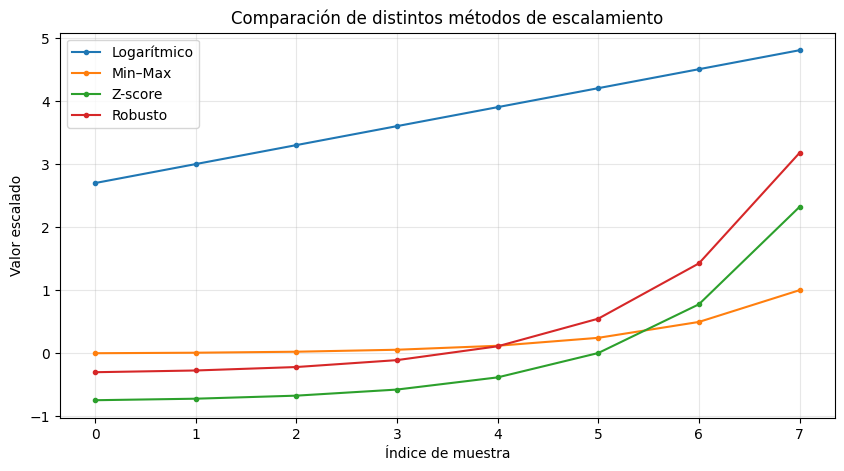

| Método          | Fórmula                           | Ventajas principales                     | Cuándo usarlo                                  |
| --------------- | --------------------------------- | ---------------------------------------- | ---------------------------------------------- |
| **Logarítmico** | $x' = \log_{10}(x)$             | Reduce asimetría, estabiliza varianza    | Datos con crecimiento exponencial o sesgo alto |
| **Min–Max**     | $x' = (x - min)/(max - min)$    | Rango fijo [0,1], mantiene proporciones  | Redes neuronales, kNN                          |
| **Z-score**     | $x' = (x - \mu)/\sigma$         | Centra y escala, facilita interpretación | Regresión, SVM, PCA                            |
| **Robusto**     | $x' = (x - \text{mediana})/IQR$ | Tolerante a outliers                     | Datos con valores extremos                     |


| Tipo               | Ejemplo            | Es lineal | Cambia forma | Objetivo                   |
| ------------------ | ------------------ | --------- | ------------ | -------------------------- |
| **Escalamiento**   | Min–Max, Z-score, Robusto   | ✅      | ❌         | Poner en rango comparable  |
| **Transformación** | Log | ❌      | ✅         | Corregir sesgo, linealizar |


---------------------------

#10 REGRESIÓN LINEAL

Calcular la Raiz Error Cuadrático Medio (rmse) y el r² para su regresión. ¿Es un buen modelo?

**Tips**
> - RMS: Idealmemte lo más cercano a 0
> - $R^2$: Idealmente lo más cercano a 1

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Seleccionamos sólo las columnas relevantes y eliminamos filas con NA
df = df[['De_1_a_4', 'mp25_menos_5']].dropna().copy()

X = df['mp25_menos_5'].values.reshape(-1, 1)
y = df['De_1_a_4'].values

# Separación única entrenamiento/prueba (no CV)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenamos la regresión lineal
model = LinearRegression()
model.fit(X_train, y_train)

# Predicción y métricas
y_pred = model.predict(X_test)
rmse_ = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse_:.3f}")
print(f"R^2: {r2:.3f}")

Graficación del modelo test en los datos

In [ ]:
# Gráfico: puntos y recta ajustada
plt.figure(figsize=(8,5))
plt.scatter(X, y, alpha=0.6, label='datos')
x_line = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_line = model.predict(x_line)
plt.plot(x_line, y_line, color='red', label='regresión lineal')
plt.xlabel('mp25 (5 días antes)')
plt.ylabel('Consultas niños 1-4')
plt.title('Regresión lineal: consultas niños 1-4 vs mp25_menos_5')
plt.legend()
plt.show()

-------------

#11 REGRESION POLINOMIAL

Regresión de polinomial de grados 2 y 3 y muestre los dos siguientes gráficos:
- Un gráfico que muestre los datos y los 2 modelos de regresión entrenados.
- Un gráfico que muestre el RMSE de entrenamiento y de prueba con respecto al grado del polinomio del modelo de regresión.
- ¿Cuál de los modelos eligiría? Justifique su respuesta.

In [ ]:
# === 3.6 REGRESIÓN POLINOMIAL ===

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

def rmse(y_true, y_pred):
    """Calcula la raíz del error cuadrático medio."""
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [ ]:
grados = []

# se hacen polinomios de 2 a 15 grados
for i in range(2, 15):
    grados.append(i)

rmse_train_list = []
rmse_test_list = []
models = {}# almacena los modelos segun su grado

In [ ]:
for g in grados:

    poly_feats = PolynomialFeatures(degree=g, include_bias=False) # Crear características polinomiales de grado g
    X_train_poly = poly_feats.fit_transform(X_train) # Transformar conjunto de entrenamiento
    X_test_poly = poly_feats.transform(X_test) # Transformar conjunto de prueba

    model = LinearRegression().fit(X_train_poly, y_train) # Entrenar modelo
    models[g] = (poly_feats, model) # Guardar modelo y transformador

    # Predicciones
    y_pred_train = model.predict(X_train_poly)
    y_pred_test = model.predict(X_test_poly)

    # RMSE
    rmse_train = rmse(y_train, y_pred_train)
    rmse_test = rmse(y_test, y_pred_test)

    rmse_train_list.append(rmse_train)
    rmse_test_list.append(rmse_test)

    if g <= 3:
        print(f"\n===== MODELO POLINOMIAL GRADO {g} =====")

        print('\n=== Conjunto de entrenamiento ===')
        print('R2 (train)', r2_score(y_train, y_pred_train))
        print('RMSE (train)', rmse_train)

        print('\n=== Conjunto de prueba ===')
        print('R2 (test)', r2_score(y_test, y_pred_test))
        print('RMSE (test)', rmse_test)

In [ ]:
# === GRÁFICO: Datos + modelos polinomiales grado 2 y 3 ===
plt.figure(figsize=(8,6))
plt.scatter(X, y, alpha=0.6, label='Datos reales')

x_line = np.linspace(X.min(), X.max(), 200).reshape(-1,1)
for g, color in zip([2,3], ['green','orange']): # zip para iterar sobre grados y colores
    poly, model = models[g]
    y_line = model.predict(poly.transform(x_line))
    plt.plot(x_line, y_line, color=color, label=f'Grado {g}')

plt.xlabel('mp25_menos_5')
plt.ylabel('Consultas niños 1–4')
plt.title('Regresión Polinomial grados 2 y 3')
plt.legend()
plt.show()

In [ ]:
# === GRÁFICO: RMSE de entrenamiento y prueba según grado ===
plt.figure(figsize=(8,5))
plt.plot(grados, rmse_train_list, marker='o', label='Entrenamiento', color='royalblue')
plt.plot(grados, rmse_test_list, marker='o', label='Prueba', color='tomato')
plt.xlabel('Grado del Polinomio')
plt.ylabel('RMSE')
plt.title('Error RMSE vs Grado del Polinomio')
plt.legend()
plt.show()

-----------------------------------------
-----------------------------------------
-----------------------------------------
-----------------------------------------
-----------------------------------------
-----------------------------------------
-----------------------------------------
-----------------------------------------

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import zipfile
import os

In [95]:
pib = pd.read_csv('data_2025/pib2020-2025.csv', encoding='utf-8', encoding_errors='replace', low_memory=False)
pib.head()

,Country,2020,2021,2022,2023,2024,2025
0,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN
1,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0
2,Algeria,164774,185850.0,225709.0,247789.0,264913.0,268885.0
3,Andorra,2885,3325.0,3376.0,3786.0,4038.0,4035.0
4,Angola,66521,84375.0,142442.0,109764.0,115946.0,113343.0


In [96]:
pib.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  196 non-null    object 
 1   2020     196 non-null    int64  
 2   2021     194 non-null    float64
 3   2022     194 non-null    float64
 4   2023     194 non-null    float64
 5   2024     192 non-null    float64
 6   2025     189 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 10.8+ KB


In [97]:
# proporcion de los nulos
# Conteo total de nulos
total = len(pib)
print(f"Total de registros: {total}")

cols = pib.columns.tolist()

for c in cols:
    nulos = pib[c].isnull().sum()
    porcentaje = (nulos / total) * 100
    print(f"Valores nulos en '{c}': {nulos} ({porcentaje:.2f}%)")

Total de registros: 196
Valores nulos en 'Country': 0 (0.00%)
Valores nulos en '2020': 0 (0.00%)
Valores nulos en '2021': 2 (1.02%)
Valores nulos en '2022': 2 (1.02%)
Valores nulos en '2023': 2 (1.02%)
Valores nulos en '2024': 4 (2.04%)
Valores nulos en '2025': 7 (3.57%)


Es infimo -> se borran los nulos

In [98]:
clean_pib = pib.copy()

In [99]:
clean_pib.dropna(inplace=True, ignore_index=True)
clean_pib.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  189 non-null    object 
 1   2020     189 non-null    int64  
 2   2021     189 non-null    float64
 3   2022     189 non-null    float64
 4   2023     189 non-null    float64
 5   2024     189 non-null    float64
 6   2025     189 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 10.5+ KB


In [100]:
# proporcion de los duplicados
# Conteo total
total = len(clean_pib)
print(f"Total de registros: {total}")

cols = clean_pib.columns.tolist()

for c in cols:
    nulos = clean_pib[c].duplicated().sum()
    porcentaje = (nulos / total) * 100
    print(f"Valores duplicados en '{c}': {nulos} ({porcentaje:.2f}%)")

Total de registros: 189
Valores duplicados en 'Country': 0 (0.00%)
Valores duplicados en '2020': 0 (0.00%)
Valores duplicados en '2021': 0 (0.00%)
Valores duplicados en '2022': 0 (0.00%)
Valores duplicados en '2023': 0 (0.00%)
Valores duplicados en '2024': 0 (0.00%)
Valores duplicados en '2025': 1 (0.53%)


Infimo la cantidad de duplicados -> los borramos

In [101]:
clean_pib.drop_duplicates(inplace=True)
clean_pib.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  189 non-null    object 
 1   2020     189 non-null    int64  
 2   2021     189 non-null    float64
 3   2022     189 non-null    float64
 4   2023     189 non-null    float64
 5   2024     189 non-null    float64
 6   2025     189 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 10.5+ KB


In [102]:
clean_pib.nunique()

Country    189
2020       189
2021       189
2022       189
2023       189
2024       189
2025       188
dtype: int64

Sin categorías

In [103]:
clean_pib.describe(include='all')

,Country,2020,2021,2022,2023,2024,2025
count,189,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02
unique,189,NaN,NaN,NaN,NaN,NaN,NaN
top,Albania,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,4.514222e+05,5.151044e+05,5.367216e+05,5.605903e+05,5.821778e+05,5.991414e+05
std,NaN,1.977386e+06,2.249103e+06,2.377764e+06,2.484240e+06,2.593048e+06,2.693421e+06
min,NaN,5.200000e+01,6.200000e+01,6.100000e+01,6.300000e+01,6.500000e+01,6.500000e+01
25%,NaN,8.628000e+03,9.484000e+03,1.253100e+04,1.240200e+04,1.337000e+04,1.421400e+04
50%,NaN,3.543200e+04,3.820900e+04,4.195300e+04,4.395800e+04,4.694300e+04,4.782900e+04
75%,NaN,2.105410e+05,2.562260e+05,2.804740e+05,2.897810e+05,2.890700e+05,3.032930e+05


In [130]:
expect = pd.read_csv('data_2025/WHO_life_expectancy.csv', encoding='utf-8', encoding_errors='replace', low_memory=False)
expect.head(3)

,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Dim1 type,Dim1,Value
0,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2021,Sex,Male,48.7 [47.8-49.7]
1,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,CAF,Central African Republic,Year,2021,Sex,Male,49.6 [48.5-50.9]
2,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2021,Sex,Both sexes,51.5 [50.5-52.6]


In [131]:
expect.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24420 entries, 0 to 24419
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   IndicatorCode        24420 non-null  object
 1   Indicator            24420 non-null  object
 2   ParentLocationCode   24420 non-null  object
 3   ParentLocation       24420 non-null  object
 4   Location type        24420 non-null  object
 5   SpatialDimValueCode  24420 non-null  object
 6   Location             24420 non-null  object
 7   Period type          24420 non-null  object
 8   Period               24420 non-null  int64 
 9   Dim1 type            24420 non-null  object
 10  Dim1                 24420 non-null  object
 11  Value                24420 non-null  object
dtypes: int64(1), object(11)
memory usage: 2.2+ MB


In [132]:
expect.duplicated().sum()

np.int64(0)

In [133]:
expect.nunique()

IndicatorCode             2
Indicator                 2
ParentLocationCode        6
ParentLocation            6
Location type             1
SpatialDimValueCode     185
Location                185
Period type               1
Period                   22
Dim1 type                 1
Dim1                      3
Value                  9937
dtype: int64

In [134]:
expect['IndicatorCode'].unique(), expect['Indicator'].unique(), expect['ParentLocationCode'].unique(), expect['ParentLocation'].unique(), expect['Period'].unique(), expect['Dim1'].unique()

(array(['WHOSIS_000001', 'WHOSIS_000015'], dtype=object),
 array(['Life expectancy at birth (years)',
        'Life expectancy at age 60 (years)'], dtype=object),
 array(['AFR', 'EMR', 'WPR', 'AMR', 'SEAR', 'EUR'], dtype=object),
 array(['Africa', 'Eastern Mediterranean', 'Western Pacific', 'Americas',
        'South-East Asia', 'Europe'], dtype=object),
 array([2021, 2020, 2019, 2018, 2017, 2016, 2015, 2014, 2013, 2012, 2011,
        2010, 2009, 2008, 2007, 2006, 2005, 2004, 2003, 2002, 2001, 2000]),
 array(['Male', 'Both sexes', 'Female'], dtype=object))

In [135]:
cols = ['IndicatorCode', 'Indicator', 'ParentLocationCode', 'ParentLocation', 'Dim1']

clean_expect = expect.copy()

for c in cols:
    clean_expect[c] = clean_expect[c].astype('category')
# renombrar columna Dim1 a sex y botar la columna Dim1 type
clean_expect.rename(columns={'Dim1': 'sex', 'Period': 'Year', 'ParentLocation': 'ParentsCountry', 'Location': 'Country'}, inplace=True)
clean_expect.drop(columns=['Dim1 type', 'Location type', 'Period type'], inplace=True)

clean_expect.sort_values(by=['Year'], ascending=[True], inplace=True, ignore_index=True)

# separar la columna 'Value' en 3 columnas: 'life_expectancy', 'lower_bound', 'upper_bound'
clean_expect[['life_expectancy', 'bound']] = clean_expect['Value'].apply(lambda x: pd.Series(str(x).split(' ')))
clean_expect[['lower_bound', 'upper_bound']] = clean_expect['bound'].apply(lambda x: pd.Series(str(x).split('-')))
clean_expect['lower_bound'] = clean_expect['lower_bound'].apply(lambda x: pd.Series(str(x).replace("[", "")))
clean_expect['upper_bound'] = clean_expect['upper_bound'].apply(lambda x: pd.Series(str(x).replace("]", "")))

clean_expect.drop(columns=['Value', 'bound'], inplace=True)

clean_expect['life_expectancy'] = clean_expect['life_expectancy'].astype(float)
clean_expect['lower_bound'] = clean_expect['lower_bound'].astype(float)
clean_expect['upper_bound'] = clean_expect['upper_bound'].astype(float)
clean_expect['Year'] = clean_expect['Year'].astype('int64')

clean_expect.head(3)

,IndicatorCode,Indicator,ParentLocationCode,ParentsCountry,SpatialDimValueCode,Country,Year,sex,life_expectancy,lower_bound,upper_bound
0,WHOSIS_000015,Life expectancy at age 60 (years),AMR,Americas,CAN,Canada,2000,Female,24.2,24.2,24.3
1,WHOSIS_000015,Life expectancy at age 60 (years),AMR,Americas,PAN,Panama,2000,Female,24.2,24.1,24.3
2,WHOSIS_000015,Life expectancy at age 60 (years),WPR,Western Pacific,NZL,New Zealand,2000,Female,24.1,24.1,24.2


In [136]:
clean_expect.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24420 entries, 0 to 24419
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   IndicatorCode        24420 non-null  category
 1   Indicator            24420 non-null  category
 2   ParentLocationCode   24420 non-null  category
 3   ParentsCountry       24420 non-null  category
 4   SpatialDimValueCode  24420 non-null  object  
 5   Country              24420 non-null  object  
 6   Year                 24420 non-null  int64   
 7   sex                  24420 non-null  category
 8   life_expectancy      24420 non-null  float64 
 9   lower_bound          24380 non-null  float64 
 10  upper_bound          24380 non-null  float64 
dtypes: category(5), float64(3), int64(1), object(2)
memory usage: 1.2+ MB


In [137]:
# Conteo total de nulos
total_registros = len(clean_expect)
print(f"Total de registros: {total_registros}")

nulos_yob = clean_expect['lower_bound'].isnull().sum()
porcentaje_nulos_yob = (nulos_yob / total_registros) * 100

nulos_citz = clean_expect['upper_bound'].isnull().sum()
porcentaje_nulos_citz = (nulos_citz/total_registros) * 100

print(f"Valores nulos en 'lower_bound': {nulos_yob} ({porcentaje_nulos_yob:.2f}%)")
print(f"Valores nulos en 'upper_bound': {nulos_citz} ({porcentaje_nulos_citz:.2f}%)")
# clean_expect.dropna(inplace=True, ignore_index=True)

Total de registros: 24420
Valores nulos en 'lower_bound': 40 (0.16%)
Valores nulos en 'upper_bound': 40 (0.16%)


In [138]:
clean_expect.describe(include='all')

,IndicatorCode,Indicator,ParentLocationCode,ParentsCountry,SpatialDimValueCode,Country,Year,sex,life_expectancy,lower_bound,upper_bound
count,24420,24420,24420,24420,24420,24420,24420.000000,24420,24420.000000,24380.000000,24380.000000
unique,2,2,6,6,185,185,NaN,3,NaN,NaN,NaN
top,WHOSIS_000001,Life expectancy at age 60 (years),EUR,Europe,CAN,Canada,NaN,Both sexes,NaN,NaN,NaN
freq,12210,12210,6600,6600,132,132,NaN,8140,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,2010.500000,NaN,44.592547,44.206661,45.010090
std,NaN,NaN,NaN,NaN,NaN,NaN,6.344419,NaN,26.456631,26.438296,26.482326
min,NaN,NaN,NaN,NaN,NaN,NaN,2000.000000,NaN,9.100000,8.700000,9.500000
25%,NaN,NaN,NaN,NaN,NaN,NaN,2005.000000,NaN,18.800000,18.400000,19.100000
50%,NaN,NaN,NaN,NaN,NaN,NaN,2010.500000,NaN,32.850000,32.500000,33.250000
75%,NaN,NaN,NaN,NaN,NaN,NaN,2016.000000,NaN,71.900000,71.500000,72.300000


In [139]:
clean_expect.describe(include='category')

,IndicatorCode,Indicator,ParentLocationCode,ParentsCountry,sex
count,24420,24420,24420,24420,24420
unique,2,2,6,6,3
top,WHOSIS_000001,Life expectancy at age 60 (years),EUR,Europe,Both sexes
freq,12210,12210,6600,6600,8140


In [140]:
clean_expect.describe()

,Year,life_expectancy,lower_bound,upper_bound
count,24420.000000,24420.000000,24380.000000,24380.000000
mean,2010.500000,44.592547,44.206661,45.010090
std,6.344419,26.456631,26.438296,26.482326
min,2000.000000,9.100000,8.700000,9.500000
25%,2005.000000,18.800000,18.400000,19.100000
50%,2010.500000,32.850000,32.500000,33.250000
75%,2016.000000,71.900000,71.500000,72.300000
max,2021.000000,87.400000,87.300000,87.400000


In [141]:
clean_pib.head(1)

,Country,2020,2021,2022,2023,2024,2025
0,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0


In [142]:
clean_expect.head(1)

,IndicatorCode,Indicator,ParentLocationCode,ParentsCountry,SpatialDimValueCode,Country,Year,sex,life_expectancy,lower_bound,upper_bound
0,WHOSIS_000015,Life expectancy at age 60 (years),AMR,Americas,CAN,Canada,2000,Female,24.2,24.2,24.3


In [143]:
# MERGE
df = pd.merge(clean_pib, clean_expect, on='Country', how='inner').drop_duplicates()
# tipos de how='inner', 'outer', 'left', 'right'
df.sort_values(inplace=True, by=['Year'], ascending=[True], ignore_index=True)

clean_df = df.copy()
# clean_df['Year'] = clean_df['Year'].astype('int64')

clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20592 entries, 0 to 20591
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Country              20592 non-null  object  
 1   2020                 20592 non-null  int64   
 2   2021                 20592 non-null  float64 
 3   2022                 20592 non-null  float64 
 4   2023                 20592 non-null  float64 
 5   2024                 20592 non-null  float64 
 6   2025                 20592 non-null  float64 
 7   IndicatorCode        20592 non-null  category
 8   Indicator            20592 non-null  category
 9   ParentLocationCode   20592 non-null  category
 10  ParentsCountry       20592 non-null  category
 11  SpatialDimValueCode  20592 non-null  object  
 12  Year                 20592 non-null  int64   
 13  sex                  20592 non-null  category
 14  life_expectancy      20592 non-null  float64 
 15  lower_bound        

In [144]:
clean_df['2020'] = clean_df['2020'].astype('float64')

In [145]:
# Conteo total de nulos
total_registros = len(clean_df)
print(f"Total de registros: {total_registros}")

cols = clean_df.columns.tolist()

for c in cols:
    nulos = clean_df[c].isnull().sum()
    porcentaje = (nulos / total_registros) * 100
    print(f"Valores nulos en '{c}': {nulos} ({porcentaje:.2f}%)")

Total de registros: 20592
Valores nulos en 'Country': 0 (0.00%)
Valores nulos en '2020': 0 (0.00%)
Valores nulos en '2021': 0 (0.00%)
Valores nulos en '2022': 0 (0.00%)
Valores nulos en '2023': 0 (0.00%)
Valores nulos en '2024': 0 (0.00%)
Valores nulos en '2025': 0 (0.00%)
Valores nulos en 'IndicatorCode': 0 (0.00%)
Valores nulos en 'Indicator': 0 (0.00%)
Valores nulos en 'ParentLocationCode': 0 (0.00%)
Valores nulos en 'ParentsCountry': 0 (0.00%)
Valores nulos en 'SpatialDimValueCode': 0 (0.00%)
Valores nulos en 'Year': 0 (0.00%)
Valores nulos en 'sex': 0 (0.00%)
Valores nulos en 'life_expectancy': 0 (0.00%)
Valores nulos en 'lower_bound': 40 (0.19%)
Valores nulos en 'upper_bound': 40 (0.19%)


In [146]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20592 entries, 0 to 20591
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Country              20592 non-null  object  
 1   2020                 20592 non-null  float64 
 2   2021                 20592 non-null  float64 
 3   2022                 20592 non-null  float64 
 4   2023                 20592 non-null  float64 
 5   2024                 20592 non-null  float64 
 6   2025                 20592 non-null  float64 
 7   IndicatorCode        20592 non-null  category
 8   Indicator            20592 non-null  category
 9   ParentLocationCode   20592 non-null  category
 10  ParentsCountry       20592 non-null  category
 11  SpatialDimValueCode  20592 non-null  object  
 12  Year                 20592 non-null  int64   
 13  sex                  20592 non-null  category
 14  life_expectancy      20592 non-null  float64 
 15  lower_bound        

In [147]:
clean_df

,Country,2020,2021,2022,2023,2024,2025,IndicatorCode,Indicator,ParentLocationCode,ParentsCountry,SpatialDimValueCode,Year,sex,life_expectancy,lower_bound,upper_bound
0,Guatemala,77718.0,86467.0,95631.0,104436.0,112575.0,121177.0,WHOSIS_000015,Life expectancy at age 60 (years),AMR,Americas,GTM,2000,Both sexes,19.8,19.7,19.8
1,Guatemala,77718.0,86467.0,95631.0,104436.0,112575.0,121177.0,WHOSIS_000015,Life expectancy at age 60 (years),AMR,Americas,GTM,2000,Female,20.7,20.7,20.8
2,Guatemala,77718.0,86467.0,95631.0,104436.0,112575.0,121177.0,WHOSIS_000001,Life expectancy at birth (years),AMR,Americas,GTM,2000,Male,65.3,64.9,65.7
3,Guatemala,77718.0,86467.0,95631.0,104436.0,112575.0,121177.0,WHOSIS_000001,Life expectancy at birth (years),AMR,Americas,GTM,2000,Both sexes,68.3,67.9,68.8
4,Samoa,869.0,844.0,833.0,938.0,1068.0,1160.0,WHOSIS_000001,Life expectancy at birth (years),WPR,Western Pacific,WSM,2000,Male,67.7,67.1,68.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20587,Albania,15271.0,18086.0,19185.0,23388.0,27259.0,28372.0,WHOSIS_000001,Life expectancy at birth (years),EUR,Europe,ALB,2021,Both sexes,76.4,76.1,76.9
20588,Albania,15271.0,18086.0,19185.0,23388.0,27259.0,28372.0,WHOSIS_000001,Life expectancy at birth (years),EUR,Europe,ALB,2021,Female,78.6,78.4,79.0
20589,Albania,15271.0,18086.0,19185.0,23388.0,27259.0,28372.0,WHOSIS_000015,Life expectancy at age 60 (years),EUR,Europe,ALB,2021,Male,18.7,18.1,19.1
20590,Albania,15271.0,18086.0,19185.0,23388.0,27259.0,28372.0,WHOSIS_000015,Life expectancy at age 60 (years),EUR,Europe,ALB,2021,Both sexes,19.9,19.6,20.4


In [148]:
clean_df.dropna(inplace=True, ignore_index=True)
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20552 entries, 0 to 20551
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Country              20552 non-null  object  
 1   2020                 20552 non-null  float64 
 2   2021                 20552 non-null  float64 
 3   2022                 20552 non-null  float64 
 4   2023                 20552 non-null  float64 
 5   2024                 20552 non-null  float64 
 6   2025                 20552 non-null  float64 
 7   IndicatorCode        20552 non-null  category
 8   Indicator            20552 non-null  category
 9   ParentLocationCode   20552 non-null  category
 10  ParentsCountry       20552 non-null  category
 11  SpatialDimValueCode  20552 non-null  object  
 12  Year                 20552 non-null  int64   
 13  sex                  20552 non-null  category
 14  life_expectancy      20552 non-null  float64 
 15  lower_bound        

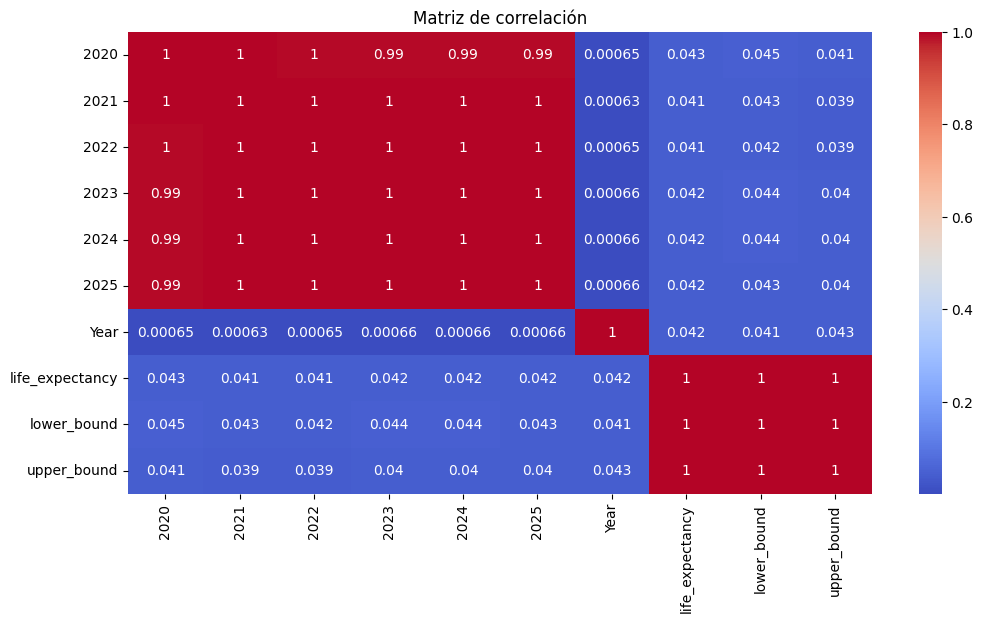

In [150]:
## Grafico de correlacion
plt.figure(figsize=(12,6))
sns.heatmap(clean_df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

In [153]:
clean_df.columns.tolist()

['Country',
 '2020',
 '2021',
 '2022',
 '2023',
 '2024',
 '2025',
 'IndicatorCode',
 'Indicator',
 'ParentLocationCode',
 'ParentsCountry',
 'SpatialDimValueCode',
 'Year',
 'sex',
 'life_expectancy',
 'lower_bound',
 'upper_bound']

Hay que escalar

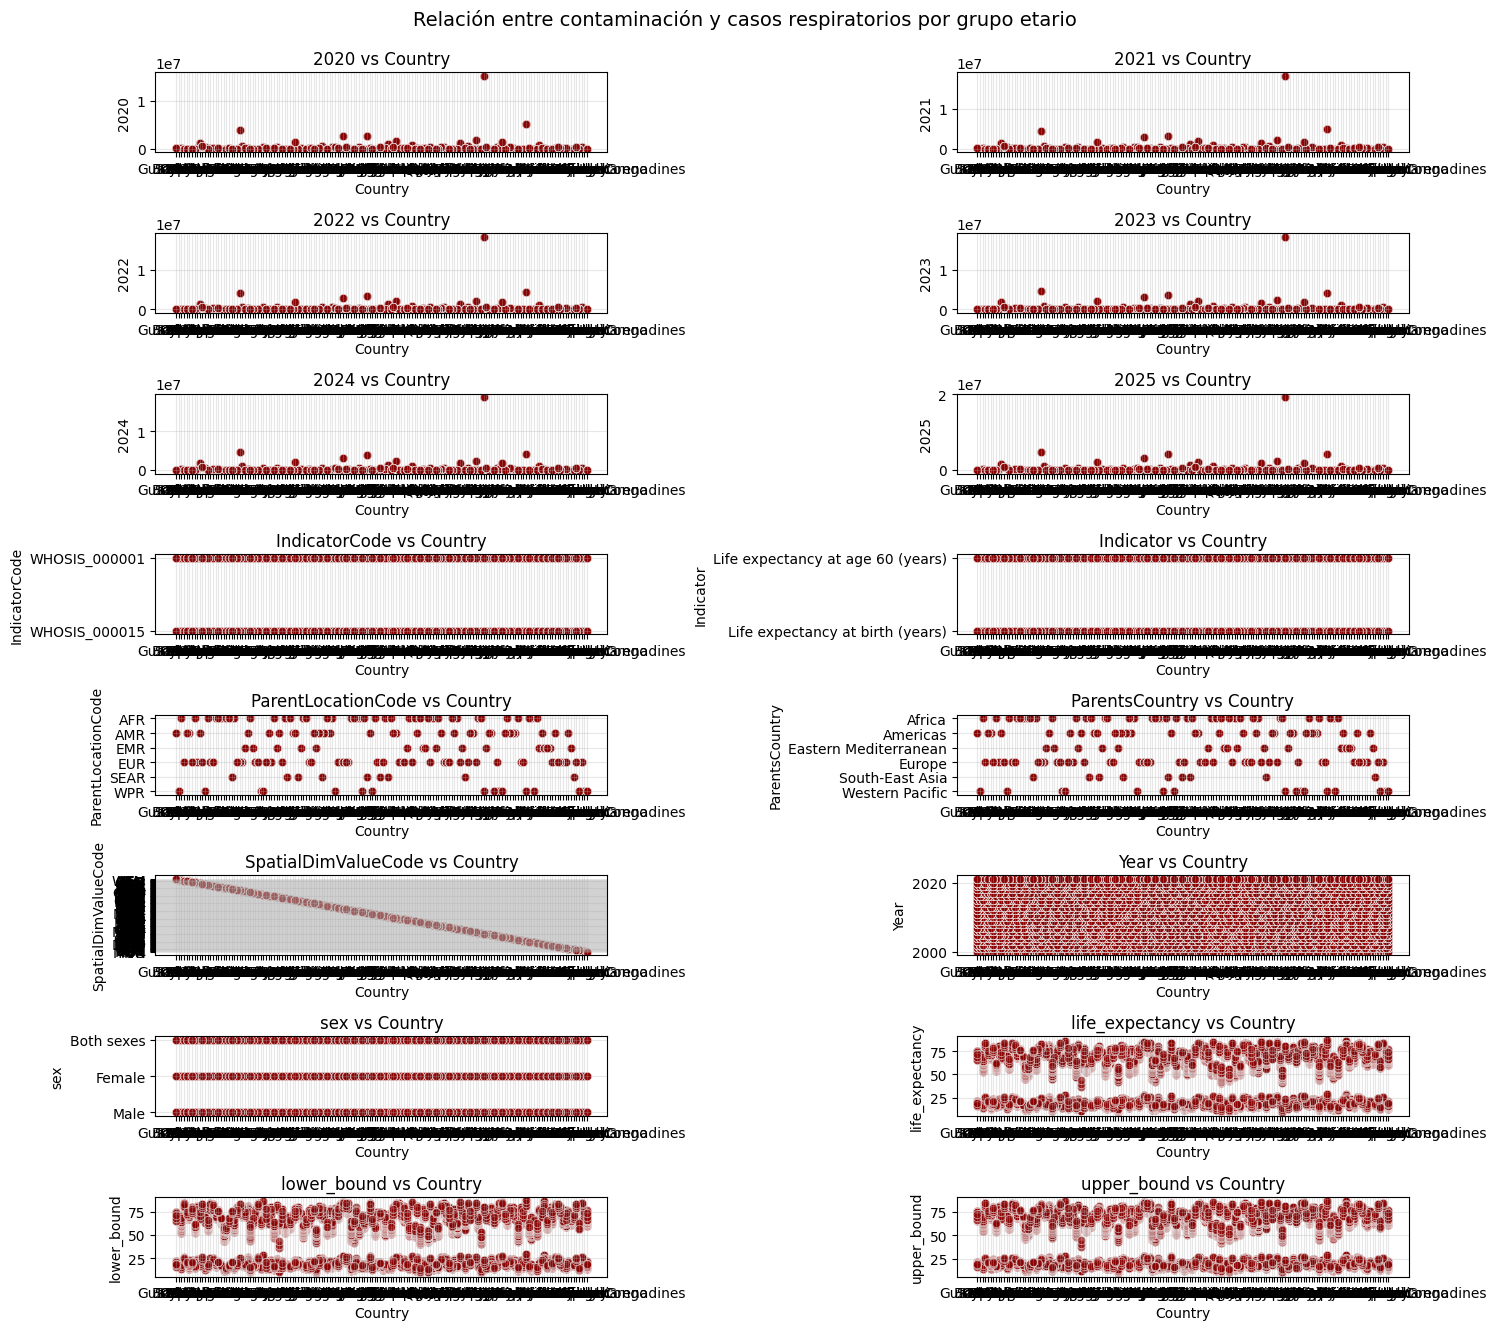

In [160]:
# Configuramos la figura
fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(15, 13))
axes = axes.flatten()

# x puede ser año, pais, 
columnas = ['2020',  '2021',  '2022',  '2023',  '2024',  '2025',  'IndicatorCode',  'Indicator',  'ParentLocationCode',  'ParentsCountry',
            'SpatialDimValueCode',  'Year', 'sex', 'life_expectancy', 'lower_bound', 'upper_bound']
# Creamos un scatterplot por cada grupo etario
for i, col in enumerate(columnas):
    # stars[col] = np.log10(stars[col])
    sns.scatterplot(data=clean_df, x='Country', y=col, ax=axes[i], color='darkred', alpha=0.7)
    axes[i].set_title(f'{col} vs Country')
    axes[i].set_xlabel('Country')
    axes[i].set_ylabel(f'{col}')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('Relación entre contaminación y casos respiratorios por grupo etario', fontsize=14, y=1.02)
plt.show()